# Southwest Power Pool load vs. weather

Hourly electricity demand for the **Southwest Power Pool** (SPP, the grid operator covering Oklahoma, Kansas,
Nebraska and parts of ten other states), from the EIA API, joined to daily temperatures from NOAA's GSOD
stations in Oklahoma, all in BigQuery.

Four questions:

1. How much of SPP's daily load variation does temperature alone explain?
2. Where is the **balance point**, the temperature at which load bottoms out?
3. How has **cooling sensitivity** (MW per cooling degree) moved year over year?
4. Can a day-ahead forecast beat a **seasonal-naive baseline**, and how does it compare with **EIA's own
   published day-ahead forecast**?

**Cost discipline.** Every query below runs with `maximum_bytes_billed`, so BigQuery refuses anything over the
cap instead of running it and charging. Each query prints the bytes it processed, and the last cell totals them.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from google.cloud import bigquery

from spp_load_weather.sql import render

# Running as yourself (gcloud application-default login) is expected here; skip the reminder.
warnings.filterwarnings("ignore", message="Your application has authenticated using end user credentials")

PROJECT = os.environ["GOOGLE_CLOUD_PROJECT"]
client = bigquery.Client(project=PROJECT, location="US")

MAX_BYTES_BILLED = 256 * 2**20  # 256 MiB per query, far above what any query here needs
ON_DEMAND_USD_PER_TIB = 6.25    # US multi-region on-demand list price, for the ledger only
ledger = []


def q(sql, label, max_bytes=MAX_BYTES_BILLED):
    # Run a query with a hard byte cap, log what it cost, return a DataFrame.
    job = client.query(sql, job_config=bigquery.QueryJobConfig(maximum_bytes_billed=max_bytes))
    rows = job.result()
    processed, billed = job.total_bytes_processed or 0, job.total_bytes_billed or 0
    ledger.append({"query": label, "processed_mib": processed / 2**20, "billed_mib": billed / 2**20})
    cached = " (served from cache, free)" if job.cache_hit else ""
    print(f"[{label}] processed {processed / 2**20:,.1f} MiB, billed {billed / 2**20:,.1f} MiB{cached}")
    # REST download instead of the BigQuery Storage Read API: results here are small,
    # and this keeps the notebook on APIs with no read charges. Plain numpy dtypes
    # instead of pandas' nullable Int64/boolean, which statsmodels formulas reject.
    return rows.to_dataframe(create_bqstorage_client=False, int_dtype=None, bool_dtype=None)


def dry_run_bytes(sql):
    # A dry run estimates bytes without running anything, and is free.
    cfg = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    return client.query(sql, job_config=cfg).total_bytes_processed


plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## The single biggest cost lever: `_TABLE_SUFFIX`

NOAA GSOD is one table per year, back to 1929. A wildcard query over `gsod*` reads **every** year unless the
suffix is filtered with a constant. Both queries below are dry runs, so the naive one is priced but never
executed.

In [2]:
naive = "SELECT stn, wban, year, mo, da, temp FROM `bigquery-public-data.noaa_gsod.gsod*`"
pruned = naive + " WHERE _TABLE_SUFFIX BETWEEN '2021' AND '2025'"

b_naive, b_pruned = dry_run_bytes(naive), dry_run_bytes(pruned)
print(f"all years:        {b_naive / 2**20:>9,.1f} MiB")
print(f"2021-2025 only:   {b_pruned / 2**20:>9,.1f} MiB")
print(f"reduction:        {b_naive / b_pruned:>9,.1f}x less data scanned")

all years:          6,256.3 MiB
2021-2025 only:       653.5 MiB
reduction:              9.6x less data scanned


## The temperature panel

Stations were picked by rule, not by hand: `sql/staging_weather_stations.sql` ranks Oklahoma stations by how many
days in the study window they actually reported a mean temperature, and keeps the top few.

In [3]:
stations = q(f"SELECT * FROM `{PROJECT}.staging.weather_stations` ORDER BY station_rank", "station panel")
stations[["station_rank", "name", "usaf", "wban", "lat", "lon", "days_observed", "completeness"]]

[station panel] processed 0.0 MiB, billed 0.0 MiB (served from cache, free)


,station_rank,name,usaf,wban,lat,lon,days_observed,completeness
0,1,GOODWELL 2 E,999999,03055,36.599,-101.595,1701,1.0000
1,2,STILLWATER 5 WNW,999999,53927,36.135,-97.108,1701,1.0000
2,3,WILL ROGERS WORLD AIRPORT,723530,13967,35.389,-97.601,1700,0.9994
3,4,TULSA INTERNATIONAL AIRPORT,723560,13968,36.199,-95.887,1700,0.9994
4,5,RICHARD LLOYD JONES JR APT,723564,53908,36.039,-95.984,1700,0.9994


In [4]:
daily = q(
    f'''
    SELECT *
    FROM `{PROJECT}.mart.load_weather_daily`
    WHERE is_complete
    ORDER BY date
    ''',
    "daily mart",
)
daily["date"] = pd.to_datetime(daily["date"])
print(f"{len(daily):,} complete days, {daily.date.min():%Y-%m-%d} to {daily.date.max():%Y-%m-%d}")
daily[["avg_load_mw", "peak_load_mw", "tavg_f", "n_stations"]].describe().round(1)

[daily mart] processed 0.0 MiB, billed 0.0 MiB (served from cache, free)


1,697 complete days, 2021-01-01 to 2025-08-28


,avg_load_mw,peak_load_mw,tavg_f,n_stations
count,1697.0,1697.0,1697.0,1697.0
mean,32373.6,36862.7,60.9,5.0
std,4695.8,6865.6,18.0,0.1
min,23703.1,25599.0,-0.6,2.0
25%,28809.1,31331.0,47.1,5.0
50%,31110.7,34788.0,63.0,5.0
75%,35299.3,41789.0,76.2,5.0
max,48701.0,56010.0,91.5,5.0


## Data quality

Staging drops hourly values outside 15-80 GW (SPP's real load has stayed between about 21 and 58 GW). Raw keeps
everything as EIA published it, so the rejected rows are listed here rather than silently disappearing. The worst
is a keying error of 3.6 million MW on 2023-06-12; left in, that single hour drops the temperature model's R^2 from
about 0.83 to about 0.51.

In [5]:
rejected = q(
    f'''
    SELECT period AS period_utc_hour_ending, type AS series, value
    FROM `{PROJECT}.raw.eia_region_data`
    WHERE ingest_date >= DATE '1970-01-01'
      AND SAFE_CAST(value AS FLOAT64) NOT BETWEEN 15000 AND 80000
    QUALIFY ROW_NUMBER() OVER (PARTITION BY type, period ORDER BY ingested_at DESC) = 1
    ORDER BY period, type
    ''',
    "rejected rows",
)
print(f"{len(rejected)} hourly values rejected")
rejected

[rejected rows] processed 0.0 MiB, billed 0.0 MiB (served from cache, free)
25 hourly values rejected


,period_utc_hour_ending,series,value
0,2023-06-13T02,D,3621097
1,2026-04-16T06,DF,2995
2,2026-04-16T07,DF,2767
3,2026-04-16T08,DF,2648
4,2026-04-16T09,DF,2671
5,2026-04-16T10,DF,2536
6,2026-04-16T11,DF,2114
7,2026-04-16T12,DF,1870
8,2026-04-16T13,DF,1599
9,2026-04-16T14,DF,4046


## Q1 and Q2: temperature explains most of the load, and the relationship is a V

Load rises when it's cold (heating) and when it's hot (cooling), so a straight line through load vs. temperature is
the wrong model. The fit below allows separate heating and cooling slopes with their own base temperatures, and
searches for the pair of base temperatures that fits best, rather than assuming the textbook 65 °F.

In [6]:
T = daily["tavg_f"].to_numpy()
y = daily["avg_load_mw"].to_numpy()


def design(t, t_heat, t_cool):
    return np.column_stack([np.ones_like(t), np.maximum(t_heat - t, 0), np.maximum(t - t_cool, 0)])


best = None
for t_heat in np.arange(40, 76, 0.5):
    for t_cool in np.arange(t_heat, 80, 0.5):
        X = design(T, t_heat, t_cool)
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        sse = float(((y - X @ coef) ** 2).sum())
        if best is None or sse < best[0]:
            best = (sse, t_heat, t_cool, coef)

sse, T_HEAT, T_COOL, COEF = best
daily["hdd"] = np.maximum(T_HEAT - daily["tavg_f"], 0)
daily["cdd"] = np.maximum(daily["tavg_f"] - T_COOL, 0)

linear = smf.ols("avg_load_mw ~ tavg_f", data=daily).fit()
v_shape = smf.ols("avg_load_mw ~ hdd + cdd", data=daily).fit()
calendar = smf.ols("avg_load_mw ~ hdd + cdd + C(day_of_week) + C(year)", data=daily).fit()

print(f"straight line in temperature        R^2 = {linear.rsquared:.3f}")
print(f"V-shape (heating + cooling sides)   R^2 = {v_shape.rsquared:.3f}")
print(f"V-shape + weekday + year effects    R^2 = {calendar.rsquared:.3f}")
print()
if T_COOL - T_HEAT < 1:
    print(f"balance point: {T_HEAT:.1f} F")
else:
    print(f"balance range: load is flat and at its minimum between {T_HEAT:.1f} F and {T_COOL:.1f} F")
print(f"heating slope: {v_shape.params['hdd']:,.0f} MW per degree below {T_HEAT:.1f} F")
print(f"cooling slope: {v_shape.params['cdd']:,.0f} MW per degree above {T_COOL:.1f} F")

straight line in temperature        R^2 = 0.118
V-shape (heating + cooling sides)   R^2 = 0.826
V-shape + weekday + year effects    R^2 = 0.915

balance range: load is flat and at its minimum between 52.0 F and 66.5 F
heating slope: 303 MW per degree below 52.0 F
cooling slope: 663 MW per degree above 66.5 F


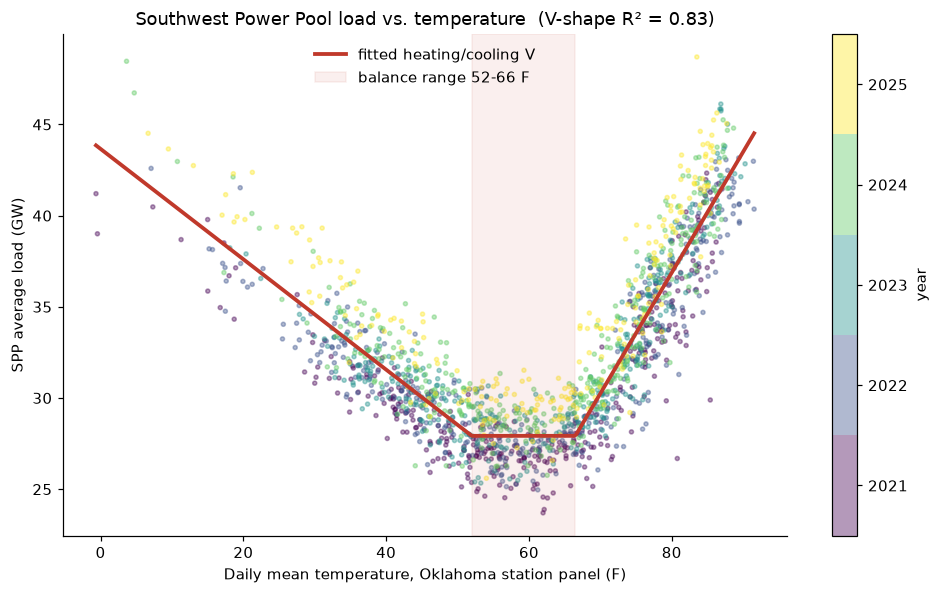

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
years = sorted(daily["year"].unique())
sc = ax.scatter(daily["tavg_f"], daily["avg_load_mw"] / 1000, s=7, alpha=0.4, c=daily["year"],
                cmap=plt.get_cmap("viridis", len(years)), vmin=years[0] - 0.5, vmax=years[-1] + 0.5)
grid = np.linspace(T.min(), T.max(), 400)
ax.plot(grid, design(grid, T_HEAT, T_COOL) @ COEF / 1000, color="#c0392b", lw=2.5, label="fitted heating/cooling V")
if T_COOL - T_HEAT >= 1:
    ax.axvspan(T_HEAT, T_COOL, color="#c0392b", alpha=0.08, label=f"balance range {T_HEAT:.0f}-{T_COOL:.0f} F")
else:
    ax.axvline(T_HEAT, color="#c0392b", ls=":", lw=1, label=f"balance point {T_HEAT:.0f} F")
ax.set_xlabel("Daily mean temperature, Oklahoma station panel (F)")
ax.set_ylabel("SPP average load (GW)")
ax.set_title(f"Southwest Power Pool load vs. temperature  (V-shape R² = {v_shape.rsquared:.2f})")
ax.legend(loc="upper center", frameon=False)
fig.colorbar(sc, ax=ax, ticks=years, label="year")
fig.tight_layout()
fig.savefig("../docs/img/load_vs_temp.png", dpi=150, bbox_inches="tight")
plt.show()

## Q3: cooling sensitivity, year by year

Same V, holding the base temperatures fixed at the values found above, fitted separately for each year with
weekday effects. The cooling coefficient is the MW of extra average load per degree above the cooling base.
Years with fewer than 300 complete days are left out.

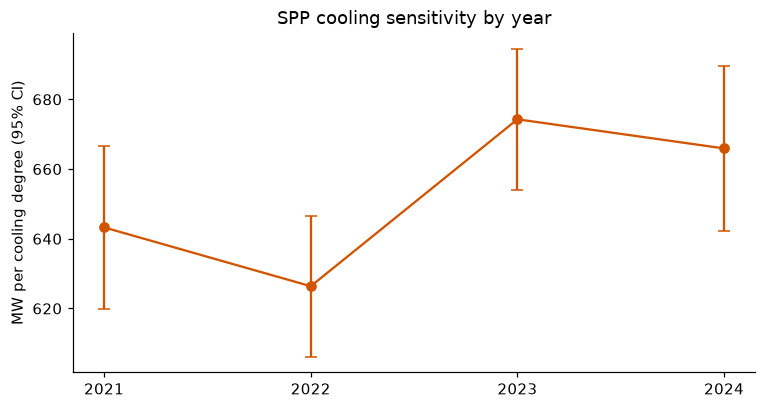

,days,mw_per_cooling_degree,ci95_low,ci95_high,mw_per_heating_degree
year,,,,,
2021,364,643.0,620.0,667.0,276.0
2022,365,626.0,606.0,647.0,295.0
2023,364,674.0,654.0,695.0,275.0
2024,364,666.0,642.0,690.0,337.0


In [8]:
rows = []
for year, g in daily.groupby("year"):
    if len(g) < 300:
        continue
    m = smf.ols("avg_load_mw ~ hdd + cdd + C(day_of_week)", data=g).fit()
    lo, hi = m.conf_int().loc["cdd"]
    rows.append({"year": year, "days": len(g), "mw_per_cooling_degree": m.params["cdd"], "ci95_low": lo,
                 "ci95_high": hi, "mw_per_heating_degree": m.params["hdd"]})
sensitivity = pd.DataFrame(rows).set_index("year")

fig, ax = plt.subplots(figsize=(8, 4))
s = sensitivity
ax.errorbar(s.index, s["mw_per_cooling_degree"],
            yerr=[s["mw_per_cooling_degree"] - s["ci95_low"], s["ci95_high"] - s["mw_per_cooling_degree"]],
            fmt="o-", capsize=4, color="#d35400")
ax.set_ylabel("MW per cooling degree (95% CI)")
ax.set_title("SPP cooling sensitivity by year")
ax.set_xticks(s.index)
plt.show()
sensitivity.round(0)

## Q4: day-ahead forecast vs. two baselines

A rolling-origin backtest: for each of the last `N_ORIGINS` complete days, train BigQuery ML `ARIMA_PLUS_XREG`
on the year of hourly load before local midnight, forecast that day's hours, then score against:

- **Seasonal naive**: the same hour one week earlier. The floor any model has to clear.
- **EIA day-ahead (DF)**: the forecast EIA publishes for SPP. The bar a real operator's model sets.

All three are scored on the same hours: only those where every method has a value. EIA published no day-ahead
forecast for SPP on 2025-08-22, so that day drops out for all three.

One caveat, stated up front: the model is given that day's *observed* temperature as its regressor, which is a
perfect temperature forecast. A production day-ahead model would only have a weather forecast, so these error
numbers are a lower bound on what it could achieve.

In [9]:
N_ORIGINS = 7
TRAIN_DAYS = 365

last_day = daily["date"].max()
days = [(last_day - pd.Timedelta(days=i)).strftime("%Y-%m-%d") for i in range(N_ORIGINS - 1, -1, -1)]
MODEL = f"{PROJECT}.mart.load_forecast_xreg"

forecasts = []
for d in days:
    # Train on everything before local midnight, then forecast exactly that local day's
    # hours (23, 24 or 25 of them, depending on DST).
    day_start = pd.Timestamp(d).tz_localize("America/Chicago")
    day_end = (pd.Timestamp(d) + pd.Timedelta(days=1)).tz_localize("America/Chicago")
    n_hours = int((day_end - day_start).total_seconds() // 3600)
    origin = f"TIMESTAMP('{d}', 'America/Chicago')"
    q(render("../sql/models/arima_plus_xreg.sql", project=PROJECT, model_name="load_forecast_xreg",
             train_start=f"TIMESTAMP_SUB({origin}, INTERVAL {TRAIN_DAYS} DAY)", train_end=origin),
      f"train {d}")
    fc = q(f'''
        SELECT forecast_timestamp AS interval_start_utc, forecast_value AS arima_mw
        FROM ML.FORECAST(
          MODEL `{MODEL}`,
          STRUCT({n_hours} AS horizon, 0.9 AS confidence_level),
          (SELECT interval_start_utc, tavg_f, hdd65, cdd65
           FROM `{PROJECT}.mart.load_weather_hourly`
           WHERE local_date = '{d}'))
        ''', f"forecast {d}")
    fc["origin_day"] = d
    forecasts.append(fc)
forecasts = pd.concat(forecasts, ignore_index=True)

[train 2025-08-22] processed 47.8 MiB, billed 48.0 MiB


[forecast 2025-08-22] processed 3.1 MiB, billed 30.0 MiB


[train 2025-08-23] processed 47.8 MiB, billed 48.0 MiB


[forecast 2025-08-23] processed 3.1 MiB, billed 30.0 MiB


[train 2025-08-24] processed 47.8 MiB, billed 48.0 MiB


...

[forecast 2025-08-26] processed 3.1 MiB, billed 30.0 MiB


[train 2025-08-27] processed 47.8 MiB, billed 48.0 MiB


[forecast 2025-08-27] processed 3.1 MiB, billed 30.0 MiB


[train 2025-08-28] processed 47.8 MiB, billed 48.0 MiB


[forecast 2025-08-28] processed 3.1 MiB, billed 30.0 MiB


In [10]:
actuals = q(
    f'''
    SELECT
      h.interval_start_utc,
      h.local_date,
      h.local_hour,
      h.load_mw,
      h.eia_forecast_mw,
      w.load_mw AS seasonal_naive_mw
    FROM `{PROJECT}.mart.load_weather_hourly` AS h
    LEFT JOIN `{PROJECT}.mart.load_weather_hourly` AS w
      ON w.interval_start_utc = TIMESTAMP_SUB(h.interval_start_utc, INTERVAL 7 DAY)
    WHERE h.local_date BETWEEN '{days[0]}' AND '{days[-1]}'
    ''',
    "backtest actuals and baselines",
)
bt = actuals.merge(forecasts, on="interval_start_utc", how="inner")
# Each hour is scored once, against the model trained at that day's local midnight.
bt = bt[bt["local_date"].astype(str) == bt["origin_day"]].dropna()

methods = {"ARIMA_PLUS_XREG": "arima_mw", "EIA day-ahead (DF)": "eia_forecast_mw",
           "Seasonal naive (t-168h)": "seasonal_naive_mw"}
scores = []
for name, col in methods.items():
    err = bt[col] - bt["load_mw"]
    scores.append({"method": name, "MAE_MW": err.abs().mean(), "RMSE_MW": np.sqrt((err**2).mean()),
                   "MAPE_pct": (err.abs() / bt["load_mw"]).mean() * 100})
scores = pd.DataFrame(scores).set_index("method")
naive_mae = scores.loc["Seasonal naive (t-168h)", "MAE_MW"]
scores["skill_vs_naive"] = 1 - scores["MAE_MW"] / naive_mae
print(f"{len(bt)} hours scored across {bt['origin_day'].nunique()} days:", bt.groupby("origin_day").size().to_dict())
scores.round(3)

[backtest actuals and baselines] processed 0.0 MiB, billed 0.0 MiB (served from cache, free)
144 hours scored across 6 days: {'2025-08-23': 24, '2025-08-24': 24, '2025-08-25': 24, '2025-08-26': 24, '2025-08-27': 24, '2025-08-28': 24}


,MAE_MW,RMSE_MW,MAPE_pct,skill_vs_naive
method,,,,
ARIMA_PLUS_XREG,2656.594,3376.488,7.750,0.684
EIA day-ahead (DF),2344.701,2844.888,6.593,0.721
Seasonal naive (t-168h),8412.812,9020.613,23.586,0.000


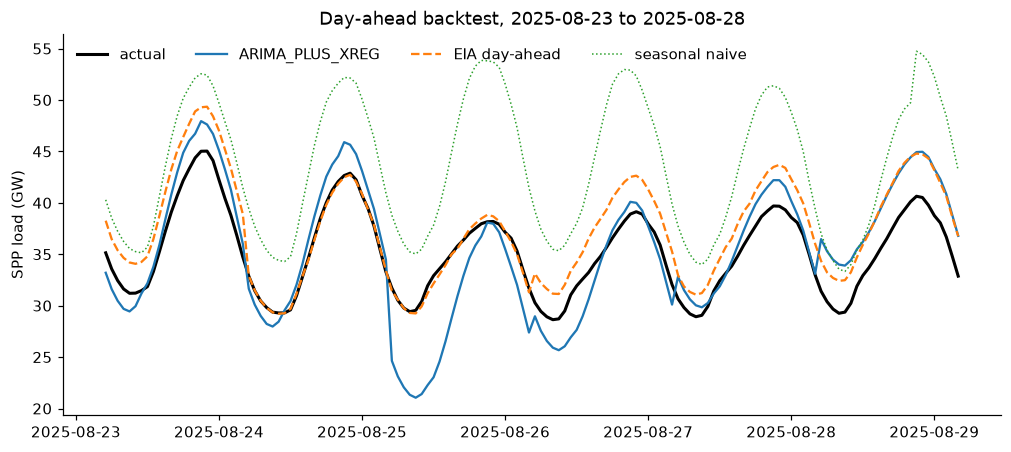

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
b = bt.sort_values("interval_start_utc")
ax.plot(b["interval_start_utc"], b["load_mw"] / 1000, color="black", lw=2, label="actual")
ax.plot(b["interval_start_utc"], b["arima_mw"] / 1000, lw=1.5, label="ARIMA_PLUS_XREG")
ax.plot(b["interval_start_utc"], b["eia_forecast_mw"] / 1000, lw=1.5, ls="--", label="EIA day-ahead")
ax.plot(b["interval_start_utc"], b["seasonal_naive_mw"] / 1000, lw=1, ls=":", label="seasonal naive")
ax.set_ylabel("SPP load (GW)")
ax.set_title(f"Day-ahead backtest, {bt['origin_day'].min()} to {bt['origin_day'].max()}")
ax.legend(ncols=4, frameon=False, loc="upper left")
plt.show()

## What this notebook cost

In [12]:
spend = pd.DataFrame(ledger)
total_billed_gib = spend["billed_mib"].sum() / 1024
print(f"{len(spend)} queries, {spend['processed_mib'].sum():,.1f} MiB processed, "
      f"{spend['billed_mib'].sum():,.1f} MiB billed")
print(f"at on-demand list price: ${total_billed_gib / 1024 * ON_DEMAND_USD_PER_TIB:,.4f} "
      f"(inside the 1 TiB/month free tier: $0.00)")
spend.round(1)

18 queries, 356.2 MiB processed, 546.0 MiB billed
at on-demand list price: $0.0033 (inside the 1 TiB/month free tier: $0.00)


,query,processed_mib,billed_mib
0,station panel,0.0,0.0
1,daily mart,0.0,0.0
2,rejected rows,0.0,0.0
3,train 2025-08-22,47.8,48.0
4,forecast 2025-08-22,3.1,30.0
5,train 2025-08-23,47.8,48.0
6,forecast 2025-08-23,3.1,30.0
7,train 2025-08-24,47.8,48.0
8,forecast 2025-08-24,3.1,30.0
9,train 2025-08-25,47.8,48.0


## Headline

In [13]:
arima, eia = scores.loc["ARIMA_PLUS_XREG"], scores.loc["EIA day-ahead (DF)"]
print(
    f"Temperature alone explains {v_shape.rsquared:.0%} of the day-to-day variation in SPP load "
    f"(a straight line explains {linear.rsquared:.0%}); load bottoms out between {T_HEAT:.0f} and {T_COOL:.0f} F "
    f"and rises about {v_shape.params['cdd']:,.0f} MW per degree of heat above that.\n"
    f"Over a {bt['origin_day'].nunique()}-day backtest ({bt['origin_day'].min()} to {bt['origin_day'].max()}), "
    f"ARIMA_PLUS_XREG scored a {arima.MAPE_pct:.1f}% MAPE, "
    f"{arima.skill_vs_naive:.0%} better than seasonal-naive, against {eia.MAPE_pct:.1f}% for EIA's own day-ahead "
    f"forecast."
)

Temperature alone explains 83% of the day-to-day variation in SPP load (a straight line explains 12%); load bottoms out between 52 and 66 F and rises about 663 MW per degree of heat above that.
Over a 6-day backtest (2025-08-23 to 2025-08-28), ARIMA_PLUS_XREG scored a 7.8% MAPE, 68% better than seasonal-naive, against 6.6% for EIA's own day-ahead forecast.


## Limitations

- **Daily weather, hourly load.** GSOD is daily, so temperature is one number per day. The regression runs on
  daily averages; the hourly forecast uses the daily temperature as its regressor and gets the within-day shape
  from seasonality.
- **Oklahoma stations for a 14-state grid.** SPP extends from the Texas Panhandle to the Dakotas. An Oklahoma
  panel is a proxy for SPP-wide weather, not a population-weighted SPP temperature.
- **Perfect temperature foresight in the backtest.** See Q4. The comparison with EIA's forecast flatters the model.
- **One balancing authority**, and EIA revisions older than the ingestion lookback window are not re-fetched.